# 02 - Exploratory analysis: what, where and when

**Questions:** What is the overall delivery performance? Where do breaches concentrate? When do they happen? What does the
SLA definition do to the headline numbers?

Every breach rate carries a 95% Wilson interval and its sample size.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "routeiq").exists())
sys.path.insert(0, str(ROOT / "src"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 110)
from routeiq.analysis import figures
figures.apply_theme()
from routeiq.config import FIGURES_DIR, TABLES_DIR, CLEANED_DELIVERY_CSV, RAW_DATA_CSV
from routeiq.features.analytical import load_analytical_dataset
df = load_analytical_dataset()
tbl = lambda name: pd.read_csv(TABLES_DIR / f"{name}.csv")
show = lambda name: display(Image(filename=str(FIGURES_DIR / name)))
say = lambda s: display(Markdown(s))
print(f"{len(df):,} deliveries loaded from the controlled analytical dataset")


43,648 deliveries loaded from the controlled analytical dataset


## What is happening? Headline KPIs


In [2]:
from routeiq.analysis import segments
K = segments.kpis(df)
display(pd.Series(K, name="value").to_frame())


,value
total_deliveries,"43,648.000"
breached_deliveries,"10,328.000"
breach_rate_pct,23.662
on_time_rate_pct,76.338
average_delivery_minutes,124.914
median_delivery_minutes,125.000
p90_delivery_minutes,195.000
p75_delivery_minutes,160.000
average_minutes_over_sla_when_breached,34.233


## How much does the SLA definition determine the headline?

The SLA threshold is each category's own P75 of delivery time, computed on the same data. So about a quarter of deliveries breach
**by construction**, and 76% on-time is not evidence of good or bad performance. Category breach rates should therefore all sit near 24%:


In [3]:
cat = tbl("segment_breach_rates").query("variable == 'category'")[["level", "n", "breach_rate", "ci_low", "ci_high"]]
say(f"Breach rate across the 16 categories ranges only **{100*cat.breach_rate.min():.1f}% - {100*cat.breach_rate.max():.1f}%**: "
    "the category cut carries almost no information. Segment cuts that do vary (traffic, area, hour, agent group) are the informative ones.")
ov = tbl("sla_sensitivity_overall"); display(ov)


Breach rate across the 16 categories ranges only **22.1% - 24.9%**: the category cut carries almost no information. Segment cuts that do vary (traffic, area, hour, agent group) are the informative ones.

,percentile,breached_deliveries,breach_rate_pct,on_time_rate_pct,expected_breach_rate_if_no_ties_pct
0,0.700,12577,28.815,71.185,30.000
1,0.750,10328,23.662,76.338,25.000
2,0.800,8310,19.039,80.961,20.000
3,0.900,4000,9.164,90.836,10.000


## Where? Traffic, weather, area, vehicle


In [4]:
seg = tbl("segment_breach_rates")
def bars(var, ax, order=None):
    t = seg[seg.variable == var]
    if order: t = t.set_index("level").loc[order].reset_index()
    else: t = t.sort_values("breach_rate")
    colors = [figures.CORAL if r == t.breach_rate.max() else figures.NAVY for r in t.breach_rate]
    ax.barh(t.level.astype(str), 100 * t.breach_rate, xerr=[100 * (t.breach_rate - t.ci_low), 100 * (t.ci_high - t.breach_rate)], color=colors, ecolor="#6B7785")
    for y, (r, n) in enumerate(zip(t.breach_rate, t.n)):
        ax.text(100 * r + 1.5, y, f"{100*r:.1f}%  (n={n:,})", va="center", fontsize=8)
    ax.set_xlim(0, 115); ax.set_title(f"Breach rate by {var}")
fig, axs = plt.subplots(2, 2, figsize=(13, 7))
bars("traffic", axs[0, 0], ["Low", "Medium", "High", "Jam"]); bars("weather", axs[0, 1]); bars("area", axs[1, 0]); bars("vehicle", axs[1, 1])
plt.tight_layout(); plt.show()


,rank,segment,n,breaches,breach_rate,share_of_breaches,cumulative_share
0,1,Metropolitian / Jam,10763,4877,0.453,0.472,0.472
1,2,Metropolitian / Medium,8080,2205,0.273,0.213,0.686
2,3,Metropolitian / High,3271,799,0.244,0.077,0.763
3,4,Urban / Jam,2555,782,0.306,0.076,0.839
4,5,Metropolitian / Low,10520,767,0.073,0.074,0.913
5,6,Urban / Medium,2286,354,0.155,0.034,0.947
6,7,Urban / High,914,131,0.143,0.013,0.960
7,8,Urban / Low,3971,131,0.033,0.013,0.973


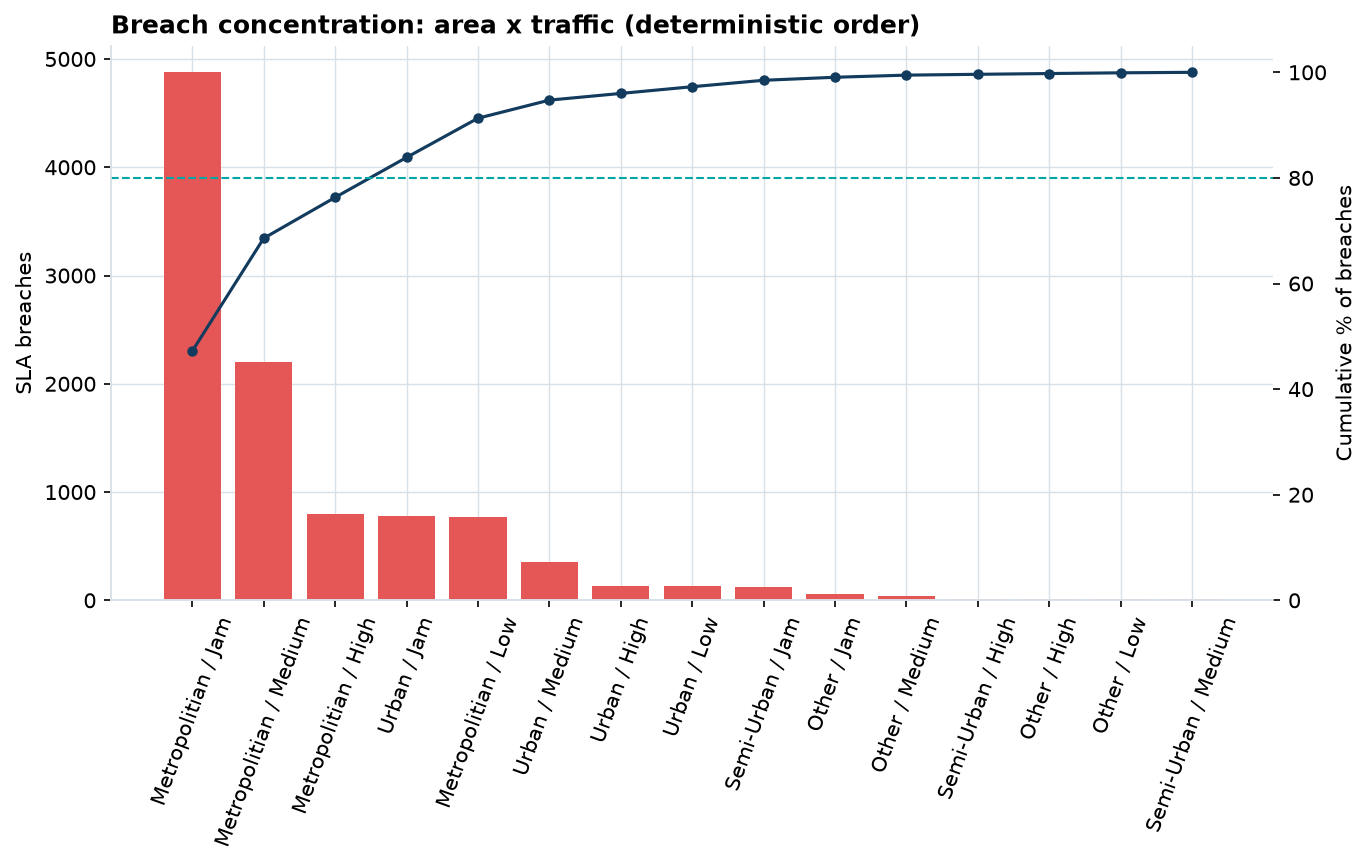

Metropolitian holds **83.7%** of breaches with **74.8%** of deliveries (lift 1.12), so its large share is mostly **volume**, not an unusually high rate. The top four area x traffic segments hold 83.9% of breaches. **Semi-Urban's 100% rate rests on only 152 deliveries** (83% in Jam traffic).

In [5]:
p = tbl("pareto_area_traffic")
display(p[["rank", "segment", "n", "breaches", "breach_rate", "share_of_breaches", "cumulative_share"]].head(8))
show("pareto_area_traffic.png")
top4 = p.cumulative_share.iloc[3]
say(f"Metropolitian holds **{100*tbl('pareto_area').cumulative_share.iloc[0]:.1f}%** of breaches with **{100*tbl('pareto_area').share_of_deliveries.iloc[0]:.1f}%** of deliveries "
    f"(lift {tbl('pareto_area').share_of_breaches.iloc[0]/tbl('pareto_area').share_of_deliveries.iloc[0]:.2f}), so its large share is mostly **volume**, not an unusually high rate. "
    f"The top four area x traffic segments hold {100*top4:.1f}% of breaches. **Semi-Urban's 100% rate rests on only 152 deliveries** (83% in Jam traffic).")


The Pareto order is now **deterministic** (breaches descending, then segment name). The v1 Power BI measure used a dense rank, so the two
tied 131-breach segments shared one cumulative value and the label repeated (97 / 97 instead of 96.0 then 97.3).


## When? Time of day


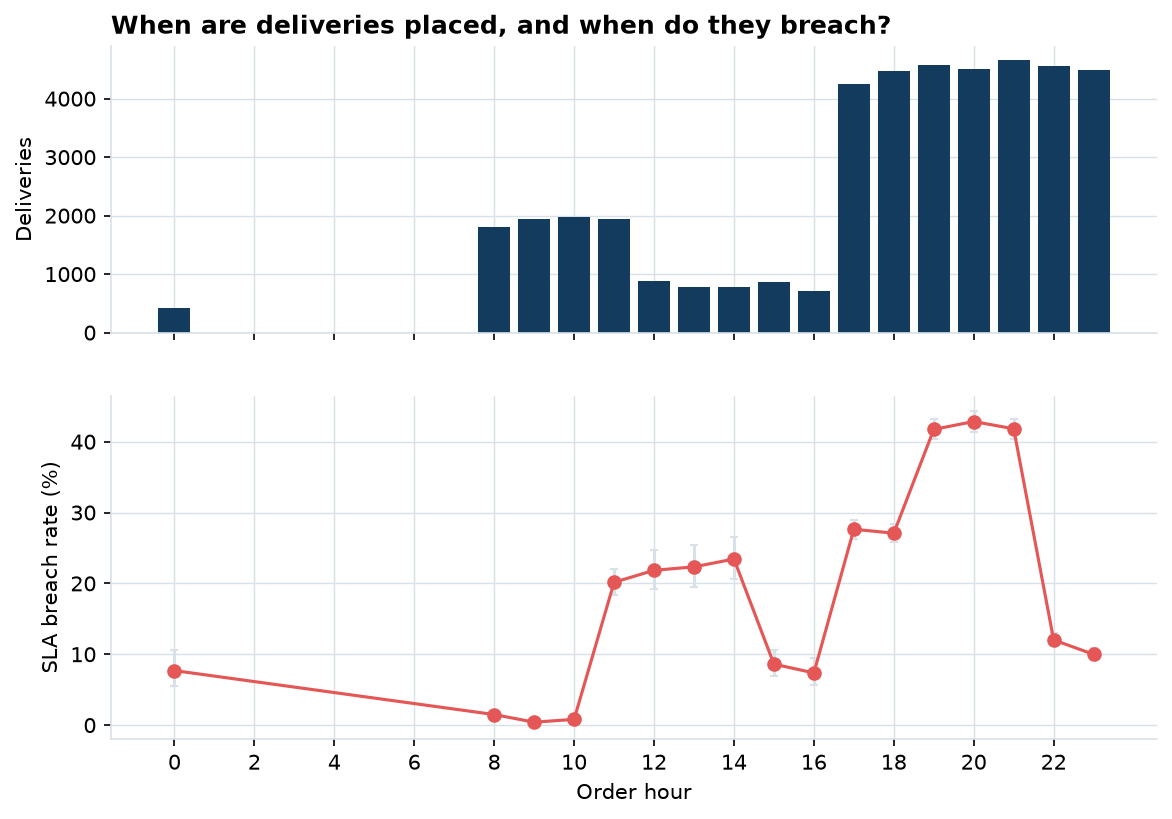

,level,n,breach_rate,ci_low,ci_high,share_of_deliveries,share_of_breaches,lift
0,1_00-07 overnight,429,0.077,0.055,0.106,0.010,0.003,0.325
1,2_08-10 morning,5724,0.009,0.007,0.012,0.131,0.005,0.038
2,3_11-14 midday,4402,0.215,0.203,0.227,0.101,0.091,0.907
3,4_15-16 afternoon,1577,0.081,0.068,0.095,0.036,0.012,0.340
4,5_17-18 early evening,8714,0.274,0.264,0.283,0.200,0.231,1.156
5,6_19-21 evening peak,13746,0.421,0.413,0.430,0.315,0.561,1.780
6,7_22-23 late evening,9056,0.110,0.104,0.117,0.207,0.097,0.465


The 17:00-23:59 peak carries **72.2%** of deliveries but **88.8%** of breaches (breach rate 29.1% vs 9.5% off-peak). Hours 19-21 alone: 31.5% of deliveries, 56.1% of breaches.

In [6]:
hp = tbl("hour_profile"); band = tbl("hour_band")
show("hour_profile.png")
display(band[["level", "n", "breach_rate", "ci_low", "ci_high", "share_of_deliveries", "share_of_breaches", "lift"]])
pk = tbl("peak_vs_offpeak").set_index("level")
say(f"The 17:00-23:59 peak carries **{100*pk.loc['peak (17-23h)','share_of_deliveries']:.1f}%** of deliveries but **{100*pk.loc['peak (17-23h)','share_of_breaches']:.1f}%** of breaches "
    f"(breach rate {100*pk.loc['peak (17-23h)','breach_rate']:.1f}% vs {100*pk.loc['off-peak','breach_rate']:.1f}% off-peak). "
    f"Hours 19-21 alone: {100*tbl('hour_band').set_index('level').loc['6_19-21 evening peak','share_of_deliveries']:.1f}% of deliveries, "
    f"{100*tbl('hour_band').set_index('level').loc['6_19-21 evening peak','share_of_breaches']:.1f}% of breaches.")


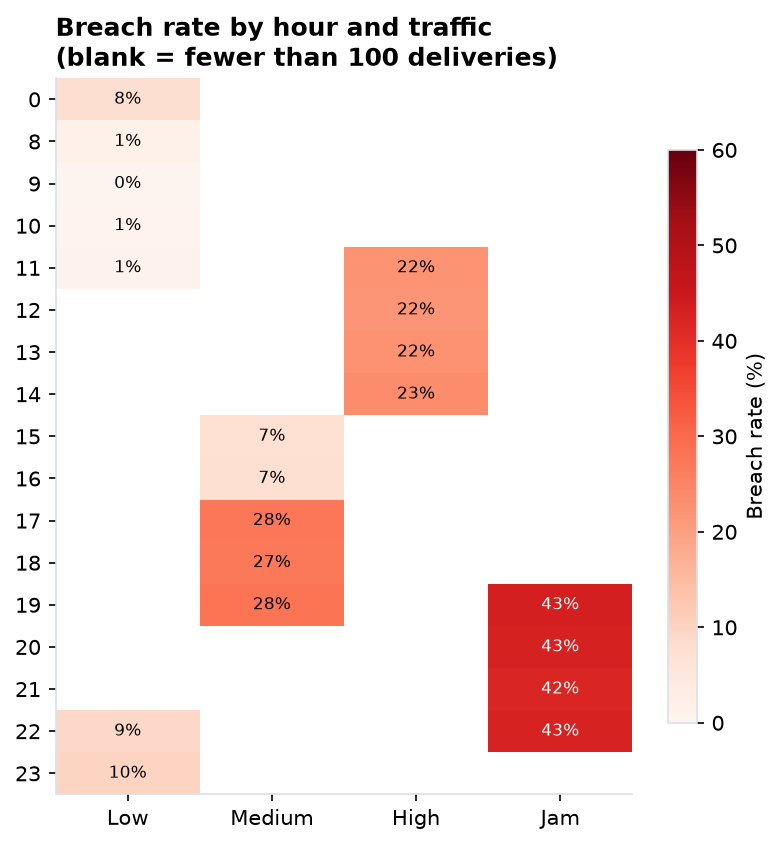

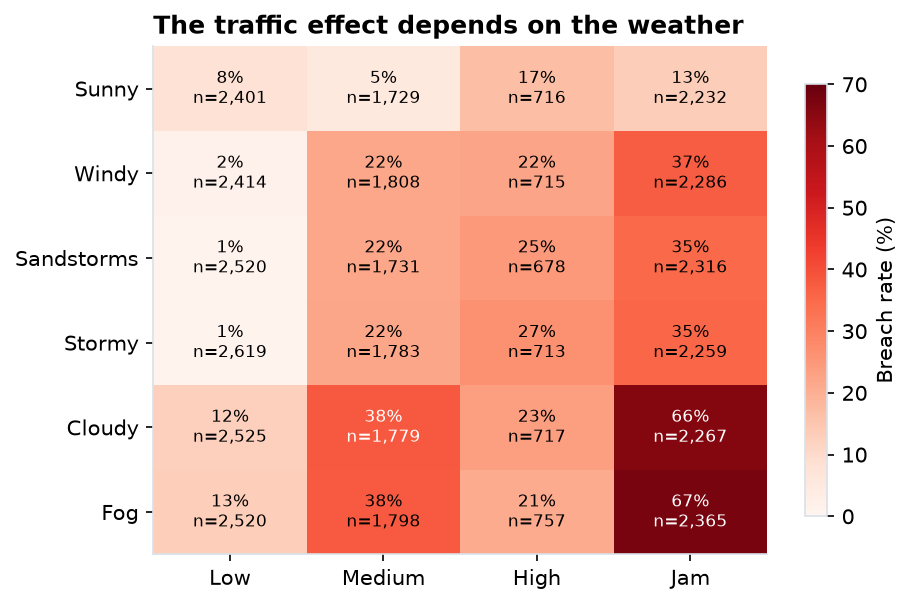

In [7]:
show("traffic_hour_heatmap.png"); show("traffic_weather_heatmap.png")


### Reading the two heatmaps
* Each traffic level lives in a narrow band of hours, so hour and traffic overlap almost completely (notebook 03 tests what can still be separated).
* **The traffic effect depends on the weather**: Jam traffic with Cloudy/Fog weather breaches about two thirds of the time, whereas Jam with Sunny weather breaches only about 13% of the time.


## Preparation time


In [8]:
display(tbl("prep_profile")[["level", "n", "breach_rate", "ci_low", "ci_high", "mean_delivery_minutes", "median_delivery_minutes"]])
import json
pt = json.load(open(ROOT / "outputs" / "results.json"))["prep_tests"]
say(f"Prep time shows **no association**: Cramer's V = {pt['cramers_v_breach_vs_prep']:.3f}, epsilon-squared = {pt['epsilon_squared_delivery_time']:.3f}, "
    f"Cohen's d (15 vs 5 min) = {pt['cohens_d_15_vs_5min']:.3f} (95% CI {pt['cohens_d_ci_low']:.3f} to {pt['cohens_d_ci_high']:.3f}). "
    "A null result is a decision: prep time is not a lever in this dataset.")


,level,n,breach_rate,ci_low,ci_high,mean_delivery_minutes,median_delivery_minutes
0,5,14617,0.238,0.231,0.245,125.365,125.000
1,10,14490,0.239,0.232,0.246,125.196,125.000
2,15,14541,0.233,0.226,0.240,124.181,125.000


Prep time shows **no association**: Cramer's V = 0.006, epsilon-squared = 0.000, Cohen's d (15 vs 5 min) = -0.023 (95% CI -0.046 to 0.000). A null result is a decision: prep time is not a lever in this dataset.